# AQI Predictor

In [ ]:
import os
import time
import json
import requests
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
BASE_DIR = "/content/drive/MyDrive/10Pearls_AQI_Project"
DATA_DIR = f"{BASE_DIR}/artifacts/data/raw"
MODEL_DIR = f"{BASE_DIR}/artifacts/models"

for path in [DATA_DIR, MODEL_DIR]:
    os.makedirs(path, exist_ok=True)

print("Directories created.")

Directories created.


### Tokens

In [ ]:
AQICN_TOKEN = "cde3737ad6588e888298cdad154e0c5922b1dccc"

In [ ]:
CITY = "Lahore"
COUNTRY = "PK"
LAT, LON = 24.8607, 67.0011

## RESUMABLE HISTORICAL BACKFILL & FEATURE ENG

In [ ]:
from tqdm.notebook import tqdm
import math
import requests
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import os

STATION_UID = -576568 # From previous step
BACKFILL_DAYS = 180   # Let's fetch 6 months of data to start (keeps API calls safe)
RAW_DATA_PATH = f"{DATA_DIR}/raw_aqi_backfill.csv"
BASE_DIR = "/content/drive/MyDrive/10Pearls_AQI_Project"
DATA_DIR = f"{BASE_DIR}/artifacts/data/raw"
os.makedirs(DATA_DIR, exist_ok=True)
ENGINEERED_DATA_PATH = f"{DATA_DIR}/engineered_features.csv"

In [ ]:
end_date = datetime(2024, 5, 20)
start_date = end_date - timedelta(days=180)

In [ ]:
print(f"Fetching data from {start_date.date()} to {end_date.date()}...")
air_url = "https://air-quality-api.open-meteo.com/v1/air-quality"
air_params = {
    "latitude": LAT,
    "longitude": LON,
    "start_date": start_date.strftime('%Y-%m-%d'),
    "end_date": end_date.strftime('%Y-%m-%d'),
    "hourly": "pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone"
}
res_air = requests.get(air_url, params=air_params).json()
df_air = pd.DataFrame(res_air['hourly'])
df_air['datetime'] = pd.to_datetime(df_air['time'])
df_air = df_air.drop('time', axis=1).set_index('datetime')

Fetching data from 2023-11-22 to 2024-05-20...


In [ ]:
weather_url = "https://archive-api.open-meteo.com/v1/archive"
weather_params = {
    "latitude": LAT,
    "longitude": LON,
    "start_date": start_date.strftime('%Y-%m-%d'),
    "end_date": end_date.strftime('%Y-%m-%d'),
    "hourly": "temperature_2m,relative_humidity_2m,wind_speed_10m,wind_direction_10m"
}
res_weather = requests.get(weather_url, params=weather_params).json()
df_weather = pd.DataFrame(res_weather['hourly'])
df_weather['datetime'] = pd.to_datetime(df_weather['time'])
df_weather = df_weather.drop('time', axis=1).set_index('datetime')

In [ ]:
df = pd.concat([df_air, df_weather], axis=1)

In [ ]:
df = df.replace(-999, np.nan)
df = df.ffill().bfill()

In [ ]:
print(f"Merged Data Fetched. Initial Shape: {df.shape}")

Merged Data Fetched. Initial Shape: (4344, 10)


In [ ]:
# Cyclical Encoding
df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek
df['month'] = df.index.month

df['hour_sin'] = np.sin(2 * np.pi * df['hour']/24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour']/24)
df['month_sin'] = np.sin(2 * np.pi * df['month']/12)
df['month_cos'] = np.cos(2 * np.pi * df['month']/12)

# Target
target_col = 'pm2_5'

# Temporal Lags & Rolling
df[f'{target_col}_lag_1'] = df[target_col].shift(1)
df[f'{target_col}_lag_24'] = df[target_col].shift(24)
df[f'{target_col}_rolling_24_mean'] = df[target_col].rolling(window=24).mean()
df[f'{target_col}_rolling_24_std'] = df[target_col].rolling(window=24).std()

# Drop only the first 24 rows lost to lag creation
df = df.dropna()

In [ ]:
df.head()

,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_direction_10m,...,dayofweek,month,hour_sin,hour_cos,month_sin,month_cos,pm2_5_lag_1,pm2_5_lag_24,pm2_5_rolling_24_mean,pm2_5_rolling_24_std
datetime,,,,,,,,,,,,,,,,,,,,,
2023-11-23 00:00:00,73.8,42.7,442.0,10.0,8.0,92.0,23.4,84,14.8,319,...,3,11,0.000000,1.000000,-0.5,0.866025,46.6,62.2,60.137500,7.567942
2023-11-23 01:00:00,70.8,41.2,658.0,27.4,8.7,71.0,22.5,89,13.5,326,...,3,11,0.258819,0.965926,-0.5,0.866025,42.7,61.5,59.291667,8.487583
2023-11-23 02:00:00,72.2,43.2,948.0,50.6,9.8,43.0,22.3,90,12.4,324,...,3,11,0.500000,0.866025,-0.5,0.866025,41.2,63.3,58.454167,9.048035
2023-11-23 03:00:00,80.6,49.6,1105.0,62.9,11.7,33.0,22.9,83,9.0,337,...,3,11,0.707107,0.707107,-0.5,0.866025,43.2,67.1,57.725000,9.026109
2023-11-23 04:00:00,78.7,47.6,996.0,53.6,14.7,56.0,24.9,65,7.4,337,...,3,11,0.866025,0.500000,-0.5,0.866025,49.6,69.4,56.816667,8.896099


In [ ]:
df.columns

Index(['pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide',
       'sulphur_dioxide', 'ozone', 'temperature_2m', 'relative_humidity_2m',
       'wind_speed_10m', 'wind_direction_10m', 'hour', 'dayofweek', 'month',
       'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'pm2_5_lag_1',
       'pm2_5_lag_24', 'pm2_5_rolling_24_mean', 'pm2_5_rolling_24_std'],
      dtype='object')

In [ ]:
unnecessary_cols = [
    'wind_speed_10m',
    'wind_direction_10m',
    'relative_humidity_2m',
    'temperature_2m',
    'pm2_5_rolling_24_mean',
    'pm2_5_rolling_24_std',
    'pm2_5_lag_24',
    'month_sin',
    'month_cos'
]

df = df.drop(columns=unnecessary_cols, errors='ignore')

In [ ]:
df.to_csv(ENGINEERED_DATA_PATH)

print(f"Feature Engineering Complete.")
print(f"Final Dataset Shape: {df.shape}")
print(f"\nQuick peek at {target_col} stats:")
print(df[target_col].describe())

Feature Engineering Complete.
Final Dataset Shape: (4320, 12)

Quick peek at pm2_5 stats:
count    4320.000000
mean       29.974537
std        14.905640
min         4.700000
25%        18.675000
50%        26.000000
75%        38.600000
max        87.300000
Name: pm2_5, dtype: float64


## MODELING, SHAP EXPLAINABILITY & ARTIFACT EXPORT

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json

from xgboost import XGBRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import shap

In [ ]:
DATA_DIR = "/content/drive/MyDrive/10Pearls_AQI_Project/artifacts/data/raw"
MODEL_DIR = "/content/drive/MyDrive/10Pearls_AQI_Project/artifacts/models"
ENGINEERED_DATA_PATH = f"{DATA_DIR}/engineered_features.csv"

df = pd.read_csv(ENGINEERED_DATA_PATH, parse_dates=['datetime'], index_col='datetime')

In [ ]:
target_col = 'pm2_5'

In [ ]:
# Calculate 1-hour change (Delta)
df['pm2_5_delta'] = df[target_col].diff()

# Lags
df['pm2_5_lag_1'] = df[target_col].shift(1)
df['pm2_5_lag_2'] = df[target_col].shift(2)
df['pm2_5_lag_3'] = df[target_col].shift(3)
df['pm2_5_lag_24'] = df[target_col].shift(24)

df = df.dropna()

In [ ]:
#### CHRONOLOGICAL SPLIT
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

features_to_drop = [target_col, 'pm2_5_delta', 'hour', 'dayofweek', 'month']
X_train = train_df.drop(features_to_drop, axis=1)
y_train_delta = train_df['pm2_5_delta']

X_test = test_df.drop(features_to_drop, axis=1)
y_test_delta = test_df['pm2_5_delta']
actual_y_test = test_df[target_col]
lag_1_test = test_df['pm2_5_lag_1']

print(f"Training samples: {len(X_train)} | Testing samples: {len(X_test)}")

Training samples: 3436 | Testing samples: 860


In [ ]:
models = {
    "Ridge_Baseline": Ridge(alpha=10.0),
    "XGBoost_Delta": XGBRegressor(
        n_estimators=100,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
}

results = {}
best_model = None
best_rmse = float('inf')
best_model_name = ""

In [ ]:
for name, model in models.items():
    # Fit model on the hour-to-hour delta
    model.fit(X_train, y_train_delta)

    # Predict the hour-to-hour change
    predicted_delta = model.predict(X_test)

    # Reconstruct absolute PM2.5 = lag_1 + predicted_delta
    final_preds = lag_1_test + predicted_delta

    rmse = np.sqrt(mean_squared_error(actual_y_test, final_preds))
    mae = mean_absolute_error(actual_y_test, final_preds)
    r2 = r2_score(actual_y_test, final_preds)

    results[name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}

    if rmse < best_rmse:
        best_rmse = rmse
        best_model = model
        best_model_name = name

In [ ]:
print("\n" + "="*40)
print("RECONSTRUCTED METRICS (ABSOLUTE PM2.5)")
print("="*40)
for name, metrics in results.items():
    print(f"{name}: RMSE={metrics['RMSE']:.2f}, MAE={metrics['MAE']:.2f}, R²={metrics['R2']:.3f}")
print(f"Winner: {best_model_name}")


RECONSTRUCTED METRICS (ABSOLUTE PM2.5)
Ridge_Baseline: RMSE=1.48, MAE=0.99, R²=0.966
XGBoost_Delta: RMSE=1.42, MAE=0.96, R²=0.968
Winner: XGBoost_Delta



Computing SHAP values using TreeExplainer...


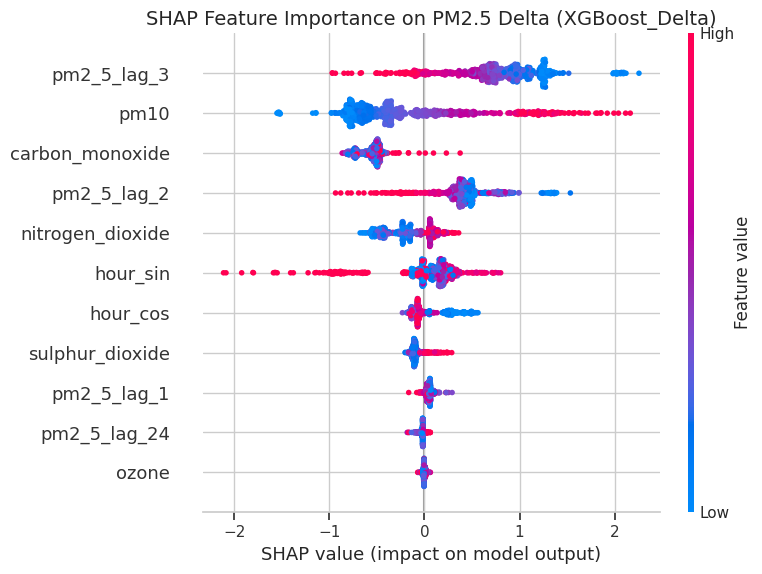

SHAP plot generated and saved.


In [ ]:
print("\nComputing SHAP values using TreeExplainer...")

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title(f"SHAP Feature Importance on PM2.5 Delta ({best_model_name})", fontsize=14)
plt.tight_layout()
plt.savefig(f"{MODEL_DIR}/shap_summary_plot.png", dpi=300, bbox_inches='tight')
plt.show()

print("SHAP plot generated and saved.")

In [ ]:
artifact = {
    'model': best_model,
    'features': list(X_train.columns),
    'target': 'pm2_5_delta',
    'metrics': results[best_model_name]
}

joblib.dump(artifact, f"{MODEL_DIR}/aqi_model_v1.joblib")

with open(f"{MODEL_DIR}/feature_schema.json", "w") as f:
    json.dump(list(X_train.columns), f)

print(f"\nProduction artifact saved to {MODEL_DIR}/aqi_model_v1.joblib")


Production artifact saved to /content/drive/MyDrive/10Pearls_AQI_Project/artifacts/models/aqi_model_v1.joblib
